In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
from pathlib import Path
import matplotlib as mpl
from matplotlib import ticker
import json


fpath = Path(mpl.get_data_path(), "computer-modern/cmunbi.ttf")

warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
#def load_model_checker_data(csv_file='/scratch/hernan/depsan-20260224-214354.csv'):

def load_model_checker_data(csv_file=f'/share/hernan/null.csv'):
    dfs = []
    for arch in ["arm", "x86"]:
        where = f'/share/hernan/{arch}.csv'
        if arch == "x86":
            larch = "x86_64"
        else:
            larch = "arm64"
        df = pd.read_csv(where)

        # Extract module and file names
        df['module_name'] = df['filename'].apply(lambda l: l.split("/")[0])
        df['entry'] = df['filename'].apply(lambda l: l.split("/")[1])
        df['arch'] = [larch] * len(df)
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

chain_columns = {
    "Module": "str",
    "Empty": "bool",
    "Segment Type": "str",
    "Dependency Type": "str",
    "Optimization Phase": "str",
    "From": "str",
    "To": "str",
    "Matched": "bool",
    "Chain ID": "str",
    "Matchable": "bool"
}

def load_dependency_data(results_dir='/share/sebastian/results/x86_64/latest'):
    """Load dependency chain data"""
    all_chains = []
    for arch in ["arm64", "x86_64"]:
        where = f'/share/sebastian/results/{arch}/PAPER'
        chains_files = glob.glob(f"{where}/**/Enhanced_Chains.csv", recursive=True)
    

        for file_path in chains_files:
            try:
                df = pd.read_csv(file_path)
                df["arch"] = [arch] * len(df)
                if len(df) > 0:
                    all_chains.append(df)
            except Exception as e:
                continue
    
    if all_chains:
        return pd.concat(all_chains, ignore_index=True)
    return pd.DataFrame()

def load_stat_data(results_dir='/share/sebastian/results/x86_64/latest'):
    """Load SA statistics"""
    lkmm_stats = []
    times = []
    for arch in ["arm64", "x86_64"]:
        where = f'/share/sebastian/results/{arch}/PAPER'
        chains_files = glob.glob(f"{where}/**/Stats.json", recursive=True)
    

        for file_path in chains_files:
            with open(file_path) as f:
                buf = json.load(f)

            clean = {}
            tmp = []
            for k in buf.keys():
                if "lkmm" in k:
                    clean[k] = buf[k]
                if "time." in k:
                    _, kind, pas, clock = k.split(".")
                    t = {"Kind":kind, "Pass":pas, "Clock":clock, "Time":buf[k]}
                    tmp.append(t)

            df = pd.DataFrame([clean])
            df["arch"] = [arch] * len(df)
            if len(df) > 0:
                lkmm_stats.append(df)
            tf = pd.DataFrame(tmp)
            tf["arch"] = [arch] * len(tf)
            if len(tf) > 0:
                times.append(tf)
        
    return pd.concat(lkmm_stats, ignore_index=True), pd.concat(times, ignore_index=True)

# Load data
df_mc = load_model_checker_data()
print(f"Loaded {len(df_mc)} completed verifications")

print("Loading dependency data...")
df_deps = load_dependency_data()
print(f"Loaded {len(df_deps)} dependency records")

print("Loading stat data...")
df_stats, df_times = load_stat_data()
print(f"Loaded {len(df_stats)} stat records")


Loaded 10422 completed verifications
Loading dependency data...
Loaded 3509251 dependency records
Loading stat data...
Loaded 48499 stat records


In [3]:

arch = "x86_64"
df_mc = df_mc[df_mc["arch"] == arch]
df_deps = df_deps[df_deps["arch"] == arch]
df_stats = df_stats[df_stats["arch"] == arch]
df_times = df_times[df_times["arch"] == arch]

In [4]:
df_times["LKMM"] = ["LKMM" in l for l in df_times["Pass"].values]

In [5]:
#print(df_mc.head())

tmp = df_deps.copy()
tmp = tmp[tmp["Optimization Phase"] == "pre-opt"]
tmp = tmp[tmp["Matched"].isin([True, False])]
tmp_matched = tmp[tmp["Matched"] == True]

stat_mods = tmp_matched["Module"].unique()
df_mc_stat = df_mc[df_mc["module_name"].isin(stat_mods)]

fake_mc_stat = df_mc[~df_mc["module_name"].isin(stat_mods)]

print(f"So far {len(stat_mods)} unique modules from static analysis")

print(f"{len(df_mc_stat["module_name"].unique())} unique modules from dynamic analysis, {len(fake_mc_stat["module_name"].unique())} from other sources")

df_mc_stat["Analysis"] = "dynamic"

So far 2623 unique modules from static analysis
1919 unique modules from dynamic analysis, 296 from other sources


In [6]:
df_matching = tmp.copy()

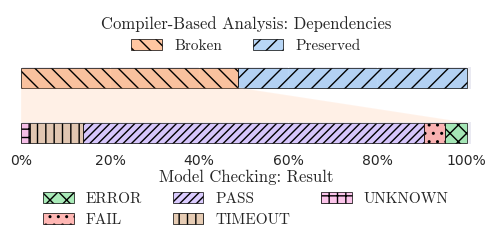

In [7]:
from matplotlib.patches import ConnectionPatch


# Create two-row horizontal stacked bar chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 1), gridspec_kw={"hspace":1.5, "left":0, "right":0.9}, sharex=True)



sns.set_context("paper")
sns.set(style="white", font="cmr10")
#sns.set_theme(style="ticks", font="cmr10")

# First row: Pre-opt chain matching status
df_preopt = df_matching[df_matching['Optimization Phase'] == 'pre-opt']
df_preopt["Dependencies"] = [ ("Preserved" if m else "Broken") for m in df_preopt["Matched"].values ]

# Plot first row
past = sns.color_palette("pastel")
mut = sns.color_palette("muted")

sns.histplot(data=df_preopt, y="Optimization Phase", hue="Dependencies", multiple="stack", stat="percent", ax=ax1,
                  palette=past, edgecolor="black", hue_order=["Preserved", "Broken"], linewidth=0.5)

#ax1.set_ylabel("Static\nAnalysis", rotation="horizontal", va="center", ha="right")
ax1.set_ylabel("")
ax1.set_title(' ')
ax1.set_xlim(0,101)

# Second row: Verification results (focusing on unmatched portion)
ok = ["PASS", "UNKNOWN", "FAIL"]
df_mc_stat["Finished"] = [ r in ok for r in df_mc_stat["result"].values ]

tmp = df_mc_stat.sort_values(by=["result"])
ax2 = sns.histplot(data=tmp, y="Analysis", hue="result", multiple="stack", stat="percent", ax=ax2,
                  palette=past[2:], edgecolor="black", linewidth=0.5)

hatches = ["\\\\", "//", "++", "||", "////", "..", "xx", "--"]
hmap = {}

i = 0
for bar in ax1.patches + ax2.patches:
    if bar.get_facecolor() not in hmap.keys():
        hmap[bar.get_facecolor()] = hatches[i]
        i += 1
    bar.set_hatch(hmap[bar.get_facecolor()])

#ax2.set_ylabel("Dynamic\nAnalysis", rotation="horizontal", va="center", ha="right")
ax2.set_ylabel("")
ax2.set_title('')
ax2.set_xlim(0,101)


ax2.set_xlabel("")
ax2.set_xticks(ticks=[0,20,40,60,80,100], labels=[ (f"{x}%") for x in [0,20,40,60,80,100] ])

sns.move_legend(ax1, "lower center", bbox_to_anchor=(0.5, 1), ncols=2, title="Compiler-Based Analysis: Dependencies")
h = ax1.get_legend().legend_handles
l = ["Preserved", "Broken"]
order = [1, 0]
ax1.legend([h[i] for i in order], [l[i] for i in order])

sns.move_legend(ax1, "lower center", bbox_to_anchor=(0.5, 1), ncols=2, title="Compiler-Based Analysis: Dependencies")

sns.move_legend(ax2, "upper center", bbox_to_anchor=(0.5, -.5), ncols=3, title="Model Checking: Result")

for hand in ax1.get_legend().legend_handles:
    hand.set_hatch(hmap[hand.get_facecolor()])
for hand in ax2.get_legend().legend_handles:
    hand.set_hatch(hmap[hand.get_facecolor()])

# Customize both axes
for ax in [ax1, ax2]:
#    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_yticks([])  # Remove y-axis ticks
    ax.tick_params(axis='x', length=0)
#    ax.grid(axis='x', alpha=0.3)
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

broken_xy_l = (ax1.patches[0].get_x(), ax1.patches[0].get_y()+ax1.patches[0].get_height())
dyn_xy_l = (ax2.patches[0].get_x(), ax2.patches[0].get_y())

line_l = ConnectionPatch(xyA=broken_xy_l, coordsA=ax1.transData,
                         xyB=dyn_xy_l, coordsB=ax2.transData,)
line_l.set_color([0,0,0,0])
fig.add_artist(line_l)


broken_xy_r = (ax1.patches[1].get_x(), ax1.patches[1].get_y()+ax1.patches[1].get_height())
dyn_xy_r = (ax2.patches[-1].get_x()+ax2.patches[-1].get_width(), ax2.patches[-1].get_y())

line_r = ConnectionPatch(xyA=broken_xy_r, coordsA=ax1.transData,
                         xyB=dyn_xy_r, coordsB=ax2.transData,)
line_r.set_color([0,0,0,0])
fig.add_artist(line_r)

coords = np.concatenate((line_l.get_path().vertices, line_r.get_path().vertices[::-1]))
#print(coords)

col = ax1.patches[0].get_facecolor()

zoom = plt.Polygon(coords,ec=None,fc=col, alpha=0.2, zorder=100, clip_on=False, closed=False)
fig.add_artist(zoom)
sns.despine(left=True, bottom=True)
sns.set(style="white", font="cmr10")

fig.tight_layout()
plt.savefig(f"percentage-{arch}.pdf", bbox_inches="tight")

In [8]:
counts = {}
total = 0
for i,r in enumerate(df_mc_stat["result"].unique()):
    tmp = len(df_mc_stat[df_mc_stat["result"]==r])
    total += tmp
    counts[r] = tmp
    print(f"{r}: {tmp}")

for k in counts.keys():
    print(f"{k}: {100*(counts[k]/total)}%")

PASS: 4120
UNKNOWN: 103
TIMEOUT: 640
FAIL: 250
ERROR: 257
PASS: 76.72253258845437%
UNKNOWN: 1.9180633147113595%
TIMEOUT: 11.91806331471136%
FAIL: 4.655493482309125%
ERROR: 4.78584729981378%


In [9]:
def k_formatter(x, pos):
    if x == 0:
        return '0'
    else:
        return f'{int(x/1000)}k'

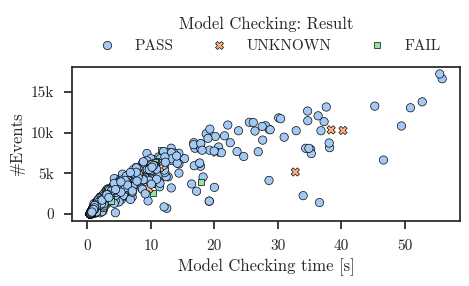

In [10]:
custom_params = {"axes.spines.right": True, "axes.spines.top": True}
sns.set_theme(style="ticks", rc=custom_params, font="cmr10")

fig, ax = plt.subplots(1, 1, figsize=(5, 2))

ax = sns.scatterplot(
    x="time",
    y="events",
    hue="result",
    style="result",
    data=df_mc_stat[df_mc_stat["Finished"] == True],
    palette=past,
    edgecolor="black",
    ax=ax
)

ax.set_title("")
#ax.grid(visible=False, axis="y")
ax.set_xlabel("Model Checking time [s]")
ax.set_ylabel("#Events")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))
#ax.set_yticks(ticks=[0,5000, 10000, 15000], labels=["0", "5k", "10k", "15k"])
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, 1), ncols=3, title="Model Checking: Result")

plt.savefig(f"da-times-{arch}.pdf", bbox_inches="tight")

In [11]:
done = np.median(df_mc_stat[df_mc_stat["Finished"]==True]["events"].values)
to_df = df_mc_stat[df_mc_stat["result"]=="TIMEOUT"].dropna()
to = np.median(to_df["events"].values)

print(f"Done: {done}; TO: {to}")

Done: 275.0; TO: 25917.5


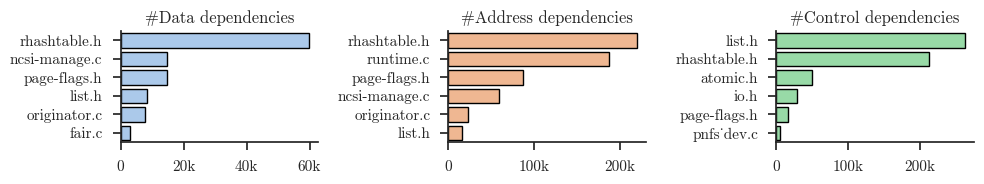

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
    
dep_types = {'Control Dependency':'#Control dependencies',
             'Data Dependency':'#Data dependencies',
             'Address Dependency':'#Address dependencies'}
limits = [30000, 100000, 150000]

class fake_bars:
    patches = []
    errorbar = None
    datavalues = []
    orientation = []
    
    
    def __init__(self, bars):
        self.patches = bars
        self.datavalues = [1 for b in bars]

#for i, dep_type in enumerate(df_deps['Dependency Type'].unique()):
for i, dep_type in enumerate(["Data Dependency", "Address Dependency", "Control Dependency"]):
    df_dep = df_deps[df_deps['Dependency Type'] == dep_type]
        
    from_counts = df_dep.groupby('From').size().nlargest(6)
    from_counts = from_counts.to_frame(name="Count").reset_index(names="From")
    axes[i] = sns.barplot(data=from_counts, y="From", x="Count", ax=axes[i], color=past[i], edgecolor="black")
    #axes[i].set(yscale="log")
    #for label in axes[i].get_xticklabels():
    #    label.set_rotation(45)
    #    label.set_fontsize(10)
    axes[i].set_title(dep_types[dep_type])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    labels = [ t.get_text() for t in axes[i].get_yticklabels() ]

    o_labels = []
    i_labels = []
    outs = []
    ins = []
    for j, c in enumerate(axes[i].containers[0]):
        if c.get_width() < limits[i]:
            outs.append(c)
            o_labels.append(labels[j])
        else:
            ins.append(c)
            i_labels.append(labels[j])
    
    #axes[i].bar_label(fake_bars(ins) , label_type="center", labels=i_labels)
    #axes[i].bar_label(fake_bars(outs), labels=o_labels, padding=5)
    #axes[i].set_yticks([])
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))

#axes[1].set_xlabel("Count", fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig(f"dep-sources-{arch}.pdf", bbox_inches="tight")

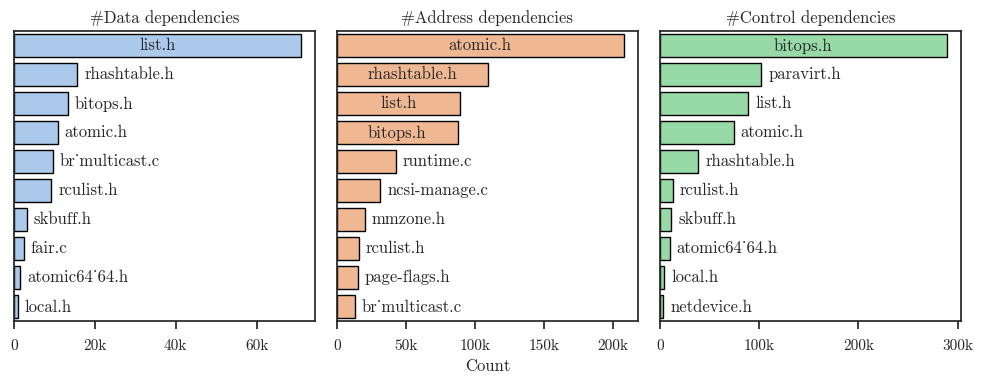

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

limits = [40000, 50000, 200000]

class fake_bars:
    patches = []
    errorbar = None
    datavalues = []
    orientation = []
    
    
    def __init__(self, bars):
        self.patches = bars
        self.datavalues = [1 for b in bars]

#for i, dep_type in enumerate(df_deps['Dependency Type'].unique()):
for i, dep_type in enumerate(["Data Dependency", "Address Dependency", "Control Dependency"]):
    df_dep = df_deps[df_deps['Dependency Type'] == dep_type]
        
    from_counts = df_dep.groupby('To').size().nlargest(10)
    from_counts = from_counts.to_frame(name="Count").reset_index(names="To")
    axes[i] = sns.barplot(data=from_counts, y="To", x="Count", ax=axes[i], color=past[i], edgecolor="black")
    #axes[i].set(yscale="log")
    #for label in axes[i].get_xticklabels():
    #    label.set_rotation(45)
    #    label.set_fontsize(10)
    axes[i].set_title(dep_types[dep_type])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    labels = [ t.get_text() for t in axes[i].get_yticklabels() ]

    o_labels = []
    i_labels = []
    outs = []
    ins = []
    for j, c in enumerate(axes[i].containers[0]):
        if c.get_width() < limits[i]:
            outs.append(c)
            o_labels.append(labels[j])
        else:
            ins.append(c)
            i_labels.append(labels[j])
    
    axes[i].bar_label(fake_bars(ins) , label_type="center", labels=i_labels)
    axes[i].bar_label(fake_bars(outs), labels=o_labels, padding=5)
    axes[i].set_yticks([])
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))


axes[1].set_xlabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig(f"dep-sinks-{arch}.pdf", bbox_inches="tight")

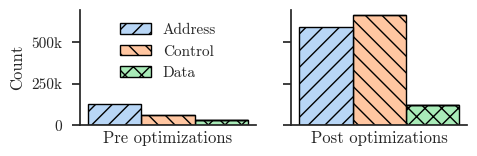

In [14]:
sns.set_theme(style="ticks", rc=custom_params, font="cmr10")
dep_types = {'Control Dependency':'Control',
             'Data Dependency':'Data',
             'Address Dependency':'Address'}
fig, axes = plt.subplots(1, 2, figsize=(5, 1.5), sharey=True)


xlabs = ["Pre optimizations", "Post optimizations"]

df_deps["Dep"] = [ dep_types[d] for d in df_deps["Dependency Type"].values]

for i, opt in enumerate(["pre-opt", "post-opt"]):
    dat = df_deps[df_deps["Optimization Phase"] == opt]
    dat = dat.sort_values(by=["Dep"])
    axes[i] = sns.histplot(
        data=dat,
        stat="count", ax=axes[i], edgecolor="black",
        x="Dependency Type", hue="Dep", palette="pastel", multiple="stack")

    axes[i].set_xticks([])
    axes[i].set_xlabel(xlabs[i])
    axes[i].yaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))
    for bar in axes[i].patches:
        bar.set_hatch(hmap[bar.get_facecolor()])


sns.move_legend(axes[0], "upper center", bbox_to_anchor=(0.5, 1), title="")
axes[1].get_legend().remove()
for hand in axes[0].get_legend().legend_handles:
    hand.set_hatch(hmap[hand.get_facecolor()])
sns.despine()
plt.savefig(f"dep-hist-{arch}.pdf", bbox_inches="tight")

In [15]:
total = [0,0]
for i, opt in enumerate(["pre-opt", "post-opt"]):
    total[i] = len(df_deps[df_deps["Optimization Phase"] == opt])
    print(f"{opt}: {total[i]}")
print(f"{total[1]/total[0]}x")

pre-opt: 219167
post-opt: 1376359
6.279955467748338x


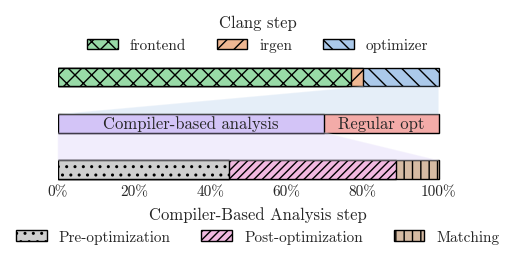

In [16]:
no_box_params = {"axes.spines.right": False, "axes.spines.top": False, "axes.spines.left":False}
sns.set_theme(style="white",rc=no_box_params, font="cmr10")

lk_passes = {"LKMMAnnotateHook": "Pre-optimization", "LKMMAnnotateDepsPass": "Post-optimization", "LKMMVerifyDepsPass":"Matching"}

fig, (clang, pa, lk) = plt.subplots(3, 1, figsize=(5, 1.5), gridspec_kw={"hspace":1, "left":0.1}, sharex=False)

df_times = df_times[df_times["Clock"] == "wall"]
df_times["Minutes"] = [ t / (60*60) for t in df_times["Time"].values]

cl_df = df_times[df_times["Kind"] == "clang"]
bars = []
slices = []
#for p in cl_df["Pass"].unique():
for p in ["frontend", "irgen", "optimizer"]:
    tmp = cl_df[cl_df["Pass"] == p]
    bars.append(tmp)
    s = pd.concat(bars, ignore_index=True)
    s["Pass"] = p
    slices.append(s)

i = 0
for s in slices[::-1]:
    clang = sns.barplot(
        data = s,
        x = "Minutes",
        hue = "Pass",
        estimator=np.sum,
        palette=past[i:],
        edgecolor="black",
        ax=clang,
        errorbar=None
    )
    i+=1

clang.xaxis.tick_top()
clang.xaxis.set_label_position('top') 
clang.tick_params(axis='x', length=0)

pa_df = df_times[df_times["Kind"] == "pass"]
bars = []
slices = []
for p in pa_df["LKMM"].unique():
    tmp = pa_df[pa_df["LKMM"] == p]
    bars.append(tmp)
    s = pd.concat(bars, ignore_index=True)
    s["LKMM"] = p
    slices.append(s)

i=0
sum_passes = np.sum(slices[-1]["Minutes"].values)
for s in slices[::-1]:
    s["Percentage"] = [ 100*(x/sum_passes) for x in s["Minutes"].values]
    pa = sns.barplot(
        data = s,
        x = "Percentage",
        hue = "LKMM",
        estimator=np.sum,
        palette=past[3+i:],
        edgecolor="black",
        ax=pa,
        errorbar=None
    )
    i+=1

pa.set_xticks([])
pa.set_xlabel("")

pa.bar_label(pa.containers[1], labels=["Regular opt"], padding=10)
pa.bar_label(pa.containers[1] , label_type="center", labels=["Compiler-based analysis"])
pa.get_legend().remove()


lk_df = df_times[df_times["LKMM"] == True]

bars = []
slices = []
#for p in lk_df["Pass"].unique():
for p in ["LKMMAnnotateHook", "LKMMAnnotateDepsPass", "LKMMVerifyDepsPass"]:
    if p not in lk_passes.keys():
        continue
    tmp = lk_df[lk_df["Pass"] == p]
    bars.append(tmp)
    s = pd.concat(bars, ignore_index=True)
    s["Pass"] = p
    slices.append(s)

i=0
sum_passes = np.sum(slices[-1]["Minutes"].values)
for s in slices[::-1]:
    s["Percentage"] = [ 100*(x/sum_passes) for x in s["Minutes"].values]
    s["Name"] = [ lk_passes[x] if x in lk_passes.keys() else None for x in s["Pass"].values]
    lk = sns.barplot(
        data = s,
        x = "Percentage",
        hue = "Name",
        estimator=np.sum,
        palette=past[5+i:],
        edgecolor="black",
        ax=lk,
        errorbar=None
    )
    i+=1

clang.set_xticks(ticks=[])
clang.set_xlabel("")


lk.set_xticks(ticks=[0,20,40,60,80,100], labels=[ (f"{x}%") for x in [0,20,40,60,80,100] ])
lk.set_xlabel("")
lk.tick_params(axis='x', pad=-3)


for topa,bota in [(clang, pa)]:
    top = topa.containers[0]
    top2 = topa.containers[1]
    bot = bota.containers[0]
    top_xy_l = (top2.patches[0].get_x()+top2.patches[0].get_width(), top2.patches[0].get_y()+top2.patches[0].get_height())
    bot_xy_l = (bot.patches[0].get_x(), bot.patches[0].get_y())

    line_l = ConnectionPatch(xyA=top_xy_l, coordsA=topa.transData,
                         xyB=bot_xy_l, coordsB=bota.transData,)
    line_l.set_color([0,0,0,0])
    fig.add_artist(line_l)


    top_xy_r = (top.patches[0].get_x()+top.patches[0].get_width(), top.patches[0].get_y()+top.patches[0].get_height())
    bot_xy_r = (bot.patches[-1].get_x()+bot.patches[-1].get_width(), bot.patches[-1].get_y())

    line_r = ConnectionPatch(xyA=top_xy_r, coordsA=topa.transData,
                         xyB=bot_xy_r, coordsB=bota.transData,)
    line_r.set_color([0,0,0,0])
    fig.add_artist(line_r)

    coords = np.concatenate((line_l.get_path().vertices, line_r.get_path().vertices[::-1]))
    #print(coords)

    col = top.patches[-1].get_facecolor()

    zoom = plt.Polygon(coords,ec=None,fc=col, alpha=0.3, zorder=100, clip_on=False, closed=False)
    fig.add_artist(zoom)

for topa,bota in [(pa, lk)]:
    top = topa.containers[-1]
    bot = bota.containers[0]
    top_xy_l = (top.patches[0].get_x(), top.patches[0].get_y()+top.patches[0].get_height())
    bot_xy_l = (bot.patches[0].get_x(), bot.patches[0].get_y())

    line_l = ConnectionPatch(xyA=top_xy_l, coordsA=topa.transData,
                         xyB=bot_xy_l, coordsB=bota.transData,)
    line_l.set_color([0,0,0,0])
    fig.add_artist(line_l)


    top_xy_r = (top.patches[0].get_x()+top.patches[0].get_width(), top.patches[0].get_y()+top.patches[0].get_height())
    bot_xy_r = (bot.patches[-1].get_x()+bot.patches[-1].get_width(), bot.patches[-1].get_y())

    line_r = ConnectionPatch(xyA=top_xy_r, coordsA=topa.transData,
                         xyB=bot_xy_r, coordsB=bota.transData,)
    line_r.set_color([0,0,0,0])
    fig.add_artist(line_r)

    coords = np.concatenate((line_l.get_path().vertices, line_r.get_path().vertices[::-1]))
    #print(coords)

    col = top.patches[-1].get_facecolor()

    zoom = plt.Polygon(coords,ec=None,fc=col, alpha=0.3, zorder=100, clip_on=False, closed=False)
    fig.add_artist(zoom)


h, l = clang.get_legend_handles_labels()
order = [2, 1, 0]
clang.legend([h[i] for i in order], [l[i] for i in order])
sns.move_legend(clang, "lower center", bbox_to_anchor=(0.5, 0.98), ncols=3, title="Clang step")

h, l = lk.get_legend_handles_labels()
order = [2, 1, 0]
lk.legend([h[i] for i in order], [l[i] for i in order])
sns.move_legend(lk, "upper center", bbox_to_anchor=(0.5, -0.5), ncols=3, title="Compiler-Based Analysis step")

hatches = ["\\\\", "//", "xx", "||", "////", "..", "++", "oo"]
hmap = {}
i = 0
for bar in clang.patches + lk.patches:
    if bar.get_facecolor() not in hmap.keys():
        hmap[bar.get_facecolor()] = hatches[i]
        i += 1
    bar.set_hatch(hmap[bar.get_facecolor()])

for ax in [clang, lk]:
    for hand in ax.get_legend().legend_handles:
        hand.set_hatch(hmap[hand.get_facecolor()])

sns.despine(left=True, bottom=True, )
plt.savefig(f"sa-times-{arch}.pdf", bbox_inches="tight")

In [17]:
total = np.sum(cl_df["Minutes"].values)
opt = np.sum(cl_df[cl_df["Pass"]=="optimizer"]["Minutes"].values)
print(f"Clang: {total}; Opt: {opt};; {opt/total}%")

total = np.sum(pa_df["Minutes"].values)
opt = np.sum(pa_df[pa_df["LKMM"]==True]["Minutes"].values)
print(f"Opts: {total}; SA: {opt}")

total = np.sum(lk_df["Minutes"].values)
for p in lk_df["Pass"].unique():
    t = np.sum(lk_df[lk_df["Pass"] == p]["Minutes"].values)
    print(f"{p}: {100*(t/total)}%;")

Clang: 260.3231876034869; Opt: 51.57751299242178;; 0.198128770115486%
Opts: 50.88708984222677; SA: 35.61517722030481
LKMMAnnotateDepsPass: 43.791325932401136%;
LKMMVerifyDepsPass: 11.273074871605505%;
LKMMAnnotateHook: 44.88120901182521%;
LKMMAnnotatePrimitives: 0.013978018606626808%;
LKMMRemoveIntrinsics: 0.040412165561521184%;
